In [1]:
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

import pandas as pd
import tqdm

from mf_chromatin_functions import *
from itertools import product

CSV matrix shape: (134, 134)


C:\Users\19162\AppData\Local\Temp\ipykernel_30144\3909336765.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(mat_csv), cmap="Reds",


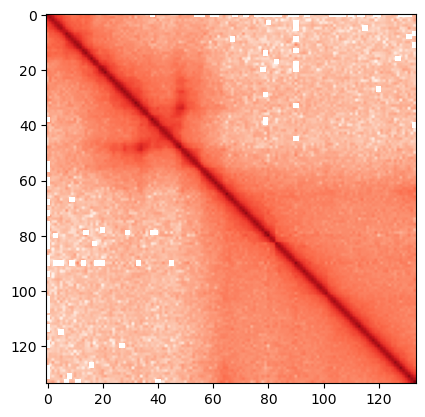

In [2]:
# CSV path auto-built from (sample, region_key, resolution)
mat_csv = read_contact_matrix(
    source="csv",
    sample="GSC275B",
    region_key="C88bex2",
    resolution=5000,
    data_dir="data",
)
print("CSV matrix shape:", mat_csv.shape)  # should now be N x N
mat = mat_csv

# (optional) Cooler example using setInvDict
# from setInvDict import coolDict
# mat_cool = read_contact_matrix(
#     source="cooler",
#     sample="GSC275B",
#     region_key="C88bex2",
#     resolution=5000,
#     coolDict=coolDict,
#     data_dir="data",
#     balance=True,
# )
# print("Cooler matrix shape:", mat_cool.shape)

plt.imshow(np.log10(mat_csv), cmap="Reds",
           #norm=plt.Normalize(vmin=0, vmax=np.percentile(mat_csv, 99))
           )

pre-processing:

1. set the threshold value

(134, 134) 0.0 1.0


C:\Users\19162\AppData\Local\Temp\ipykernel_30144\1515027306.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(proc), cmap="Reds",)


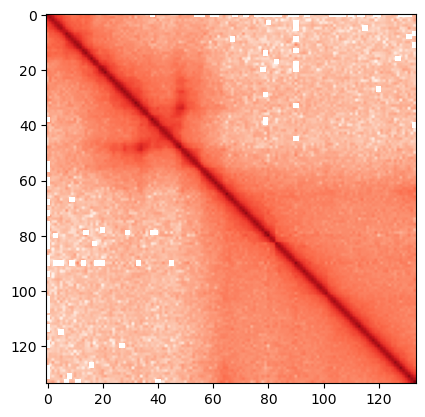

In [3]:

# 2) preprocess (defaults mirror the original script’s behavior)
#    - try a typical cfmax grid candidate, e.g. 0.10
#    - keep Gaussian filtering off unless you want it
proc, info = preprocess_contact_matrix(
    mat,
    sig=None,              # e.g. 1.0 to enable Gaussian smoothing
    Cnanflag='nanlow',     # original default
    Clowpp=5.0,            # percentile for “nanlow” strategy. not acutally used
    Chighpp=95.0,           # not acutally used
    cfmax=0.0,            # cap at 10% of max before normalization (grid value in the original runs)
    normalize=True,
    zero_diagonal=False,
    return_info=True
)

print(proc.shape, proc.min(), proc.max())  # N×N, ~[0,1]
# info['distance_profiles']['p_high'] etc. are available if you want to inspect.
plt.imshow(np.log10(proc), cmap="Reds",)

2. set matrix to log scale, and fill the nan values

C:\Users\19162\AppData\Local\Temp\ipykernel_30144\807924705.py:1: RuntimeWarning: divide by zero encountered in log10
  processed_log_matrix = fill_nearest(np.log10(proc))


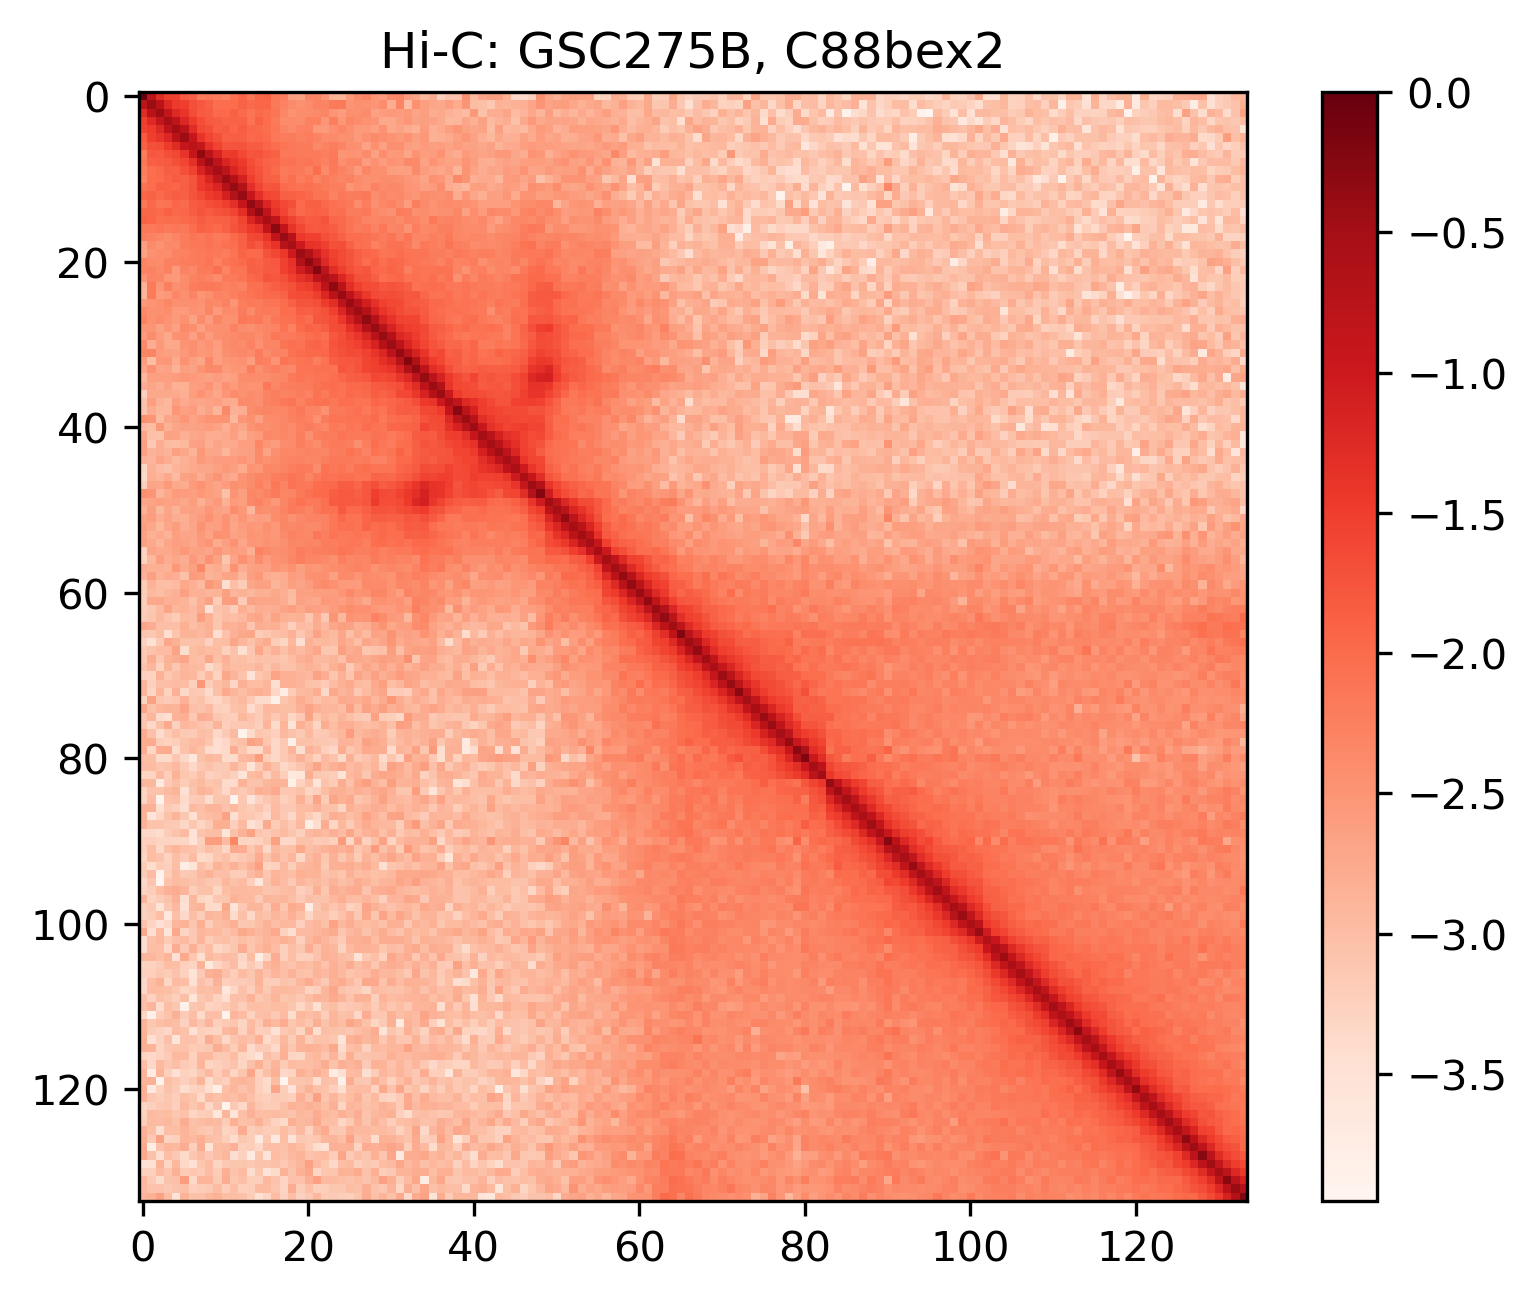

In [4]:
processed_log_matrix = fill_nearest(np.log10(proc))
plt.figure(dpi=300)
plt.imshow(processed_log_matrix, cmap="Reds",)
plt.title("Hi-C: GSC275B, C88bex2")
plt.colorbar()

Load to profiles (open and globule) to construct matrix

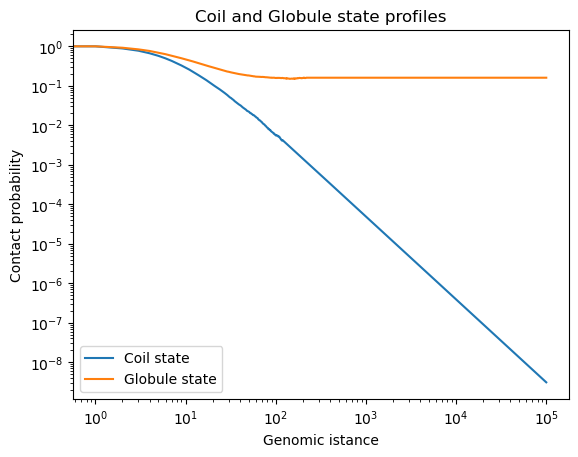

In [5]:
profile_start = 0

def load_contact_profiles(profile_start):
    """Load pre-computed contact probability profiles for coil and globule phases."""
    coil_profile = pd.read_csv(
        'data/'+ 'coilPhase_polymerContactProbabilityProfile.csv',
        sep=',', index_col=0
    )
    
    globule_profile = pd.read_csv(
        'data/' + 'globulePhase_polymerContactProbabilityProfile.csv',
        sep=',', index_col=0
    )
    
    #print(f"✓ Loaded coil profile: {coil_profile.shape[0]} data points")
    #print(f"✓ Loaded globule profile: {globule_profile.shape[0]} data points")
    
    return np.array(coil_profile)[profile_start:,0], np.array(globule_profile)[profile_start:,0]

coil_profile, globule_profile = load_contact_profiles(profile_start)

plt.loglog(coil_profile, label='Coil state')
plt.loglog(globule_profile, label='Globule state')
plt.title(("Coil and Globule state profiles"))
plt.xlabel("Genomic istance")
plt.ylabel("Contact probability")
plt.legend()

Initialize the polymer configuration

804


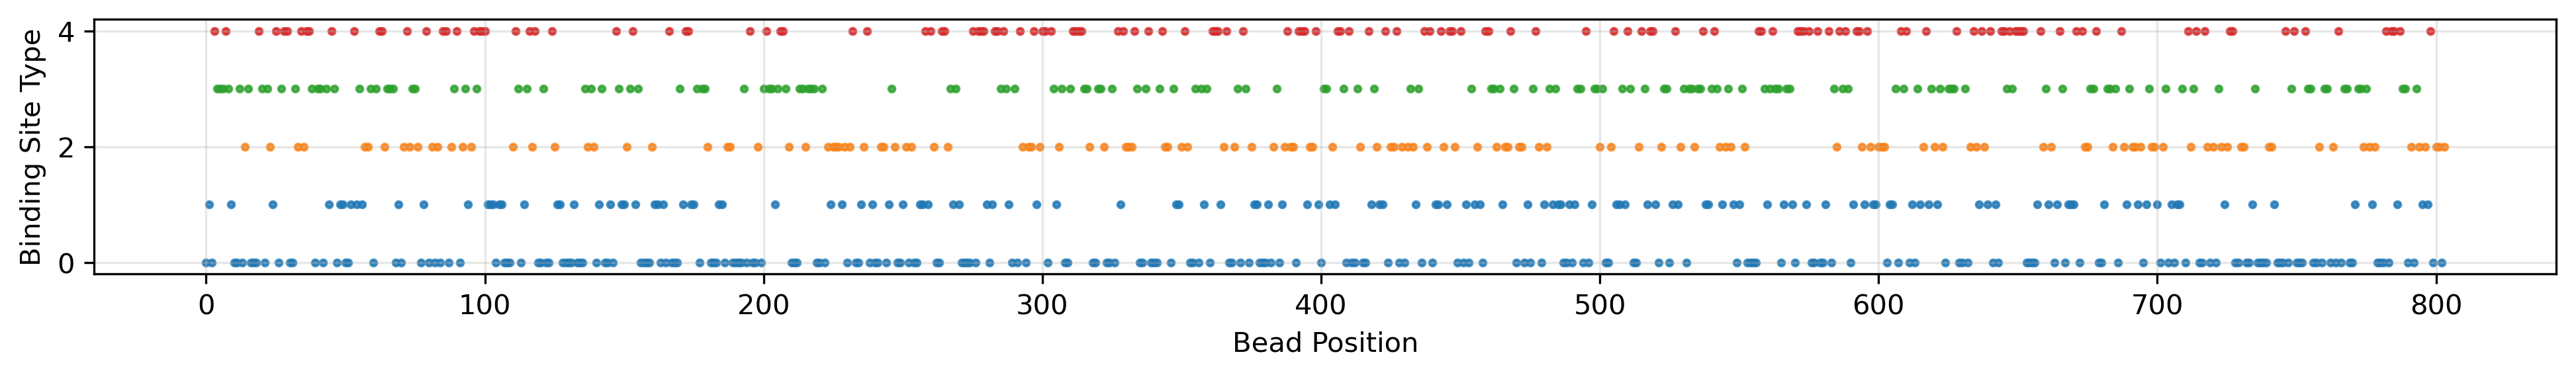

In [6]:
R = processed_log_matrix.shape[0] # resolution of the Hi-C data
N = 6 # beads correcponding to one pixel in Hi-C
NR = N*R
print(NR)
K = 12 # number of class of beads

def config_alternating(NR, K, num_alt):
    index = np.arange(NR)
    period = 2 * NR // num_alt
    config_alt = np.where((index % period) < (period//2), 0, 1)
    return config_alt

config_alt = config_alternating(NR, 2, 5)

def config_triple(NR, K, num_alt):
    index = np.arange(NR)
    period = 3 * NR // num_alt
    config_alt = np.where((index % period) < (period//3), 0, 
                          np.where((index % period) < (2*period//3), 1, 2))
    return config_alt

config_tri = config_triple(NR, 3, 10)

config_random = np.random.randint(0, K, NR, dtype=np.int_)

#visualize_config(config_tri, num_classes=3)

#plt.scatter(np.arange(len(config_tri)), config_tri)

def initial_config(NR, K, prob_inert):
    probs = np.zeros(K)
    probs[0] = prob_inert
    probs[1:] = (1 - prob_inert) / (K - 1)
    config_inert = np.random.choice(K, NR, p=probs)

    return config_inert

config_inert = initial_config(NR, 5, 0.3) # beads,

visualize_config(config_inert, num_classes=K)

Constructing contact matrix, based on the initialized sequence


Text(0.5, 1.0, 'random clustered, mostly class 0')

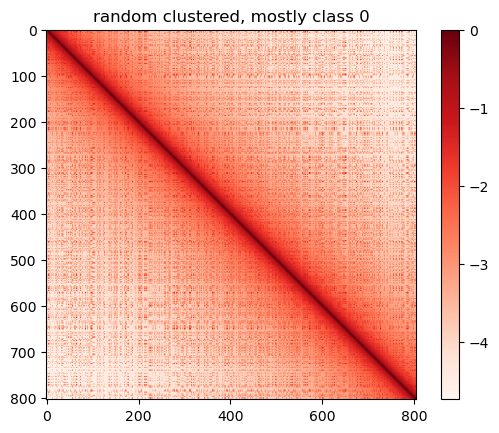

In [7]:
rand_mat_construct = contstruct_contact_matrix(
    alpha=0.5,
    alpscal=0.5,
    polymer_config=config_inert,
    coil_profile=coil_profile,
    globule_profile=globule_profile,
    distance_matrix=distance_index(NR)
)

plt.imshow(np.log10(rand_mat_construct), cmap="Reds",)
plt.colorbar()
plt.title("random clustered, mostly class 0")

Aligning the decay profile's level between theoretical and experimental input.

The constructed matrix is multiplied by a multiplier. This multiplier value is later used for reconstruction during the simulated annealing

In [39]:
def single_run(mat_multiplier, contour_scale, polymer_config):

    decay, horiz, vert = diagonal_decay_profile(processed_log_matrix, agg="mean", normalize=False)

    mat_construct = np.log10(contstruct_contact_matrix(
        alpha=1,
        alpscal=contour_scale, # zoom the contour scale, lower: narrower
        polymer_config=polymer_config,
        coil_profile=coil_profile,
        globule_profile=globule_profile,
        distance_matrix=distance_index(NR)
    ))
    mat_construct *= mat_multiplier
    zoomed_construct_mat = gaussian_then_stride(mat_construct, N, sigma=None, mode='reflect')
    decay2, horiz, vert = diagonal_decay_profile(zoomed_construct_mat, agg="mean", normalize=False)

    contour_distance = np.arange(len(decay))
    contour_log_distance = np.log10(contour_distance[1:])
    uniform_scale = np.linspace(np.min(contour_log_distance), np.max(contour_log_distance), 100)
    decay_uniform = np.interp(uniform_scale, contour_log_distance, decay[1:])
    decay2_uniform = np.interp(uniform_scale, contour_log_distance, decay2[1:])

    area_diff = np.trapz(np.abs(decay_uniform - decay2_uniform), uniform_scale)

    return area_diff

def parameter_sweep_2d(mat_multis, c_scales, polymer_config, n_jobs=-1, backend="loky"):



    combos = list(product(mat_multis, c_scales))  # order: outer over Ns, inner over phibars

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(single_run)(mat_multiplier, contour_scale, polymer_config) for (mat_multiplier, contour_scale) in
        combos
        #tqdm(combos, total = len(combos))
    )
    diff_list = results

    M, K = len(mat_multis), len(c_scales)
    diff_grid = np.empty((M, K), dtype=object)

    # Fill grids in the same order as product(Ns, phibars)
    idx = 0
    for i in range(M):
        for j in range(K):
            diff_grid[i, j] = diff_list[idx]
            idx += 1

    return mat_multis, c_scales, np.array(diff_grid)

In [12]:
mat_multiplier =  0.5125252525252526
contour_scale =  0.050202020202020206

In [40]:
mat_multis = np.linspace(0.01, 2, 100)
c_scales = np.linspace(0.01, 2, 100)
mat_multis, c_scales, diff_grid = parameter_sweep_2d(mat_multis, c_scales, config_inert)
flat_idx = np.argmin(diff_grid)
row_idx, col_idx = np.unravel_index(flat_idx, diff_grid.shape)
#print(row_idx, col_idx)
print("best intensity multiplier = ", mat_multis[row_idx])
print("best contour zoom factor = ", c_scales[col_idx])

mat_multiplier = mat_multis[row_idx]
contour_scale = c_scales[col_idx]

best intensity multiplier =  0.5728282828282829
best contour zoom factor =  0.0904040404040404


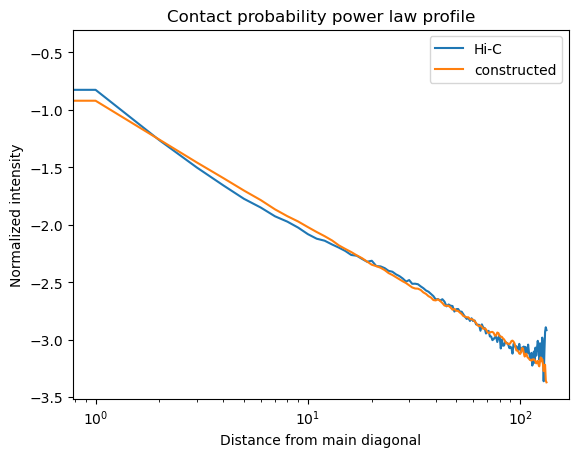

0.08922287465258723


In [41]:

decay, horiz, vert = diagonal_decay_profile(processed_log_matrix, agg="mean", normalize=False)

mat_construct = np.log10(contstruct_contact_matrix(
    alpha=1,
    alpscal=contour_scale, # zoom the contour scale, lower: narrower
    polymer_config=config_inert,
    coil_profile=coil_profile,
    globule_profile=globule_profile,
    distance_matrix=distance_index(NR)
))
mat_construct *= mat_multiplier
zoomed_construct_mat = gaussian_then_stride(mat_construct, N, sigma=None, mode='reflect')
decay2, horiz, vert = diagonal_decay_profile(zoomed_construct_mat, agg="mean", normalize=False)

contour_distance = np.arange(len(decay))

plt.plot(contour_distance, decay, label = "Hi-C")
plt.plot(contour_distance, decay2, label = "constructed")
plt.xlabel("Distance from main diagonal")
plt.ylabel("Normalized intensity")
plt.xscale("log")
#plt.xlim(left = 2)
plt.title("Contact probability power law profile")
plt.legend()
plt.show()

# calculate difference

contour_log_distance = np.log10(contour_distance[1:])
uniform_scale = np.linspace(np.min(contour_log_distance), np.max(contour_log_distance), 100)
decay_uniform = np.interp(uniform_scale, contour_log_distance, decay[1:])
decay2_uniform = np.interp(uniform_scale, contour_log_distance, decay2[1:])

area_diff = np.trapz(np.abs(decay_uniform - decay2_uniform), uniform_scale)
print(area_diff)

In [42]:
def clustering_entropy_penalty(labels: np.ndarray) -> float:
    """
    Parameter-free, entropy-like penalty that prefers clustered classes.
    Lower is better (more clustered). Range ~ [0, 1].

    Computes the normalized entropy rate H(C_t | C_{t-1}) / log(K),
    using empirical transitions along the 1D polymer chain.
    """
    lab = np.asarray(labels)
    N = lab.size
    if N < 2:
        return 0.0

    # Map arbitrary integer labels to 0..K-1 (handles gaps like {0,2,7,...})
    uniq, inv = np.unique(lab, return_inverse=True)
    K = uniq.size
    if K <= 1:
        return 0.0

    prev = inv[:-1]
    nxt  = inv[1:]

    # Build transition count matrix in O(N)
    counts = np.bincount(prev * K + nxt, minlength=K*K).reshape(K, K).astype(np.float64)

    row_tot = counts.sum(axis=1, keepdims=True)              # transitions out of each state
    total   = row_tot.sum()
    if total == 0:
        return 0.0

    # Row-normalize to conditional probabilities P(nxt | prev)
    valid = row_tot.squeeze() > 0
    P = np.zeros_like(counts)
    P[valid] = counts[valid] / row_tot[valid]

    # Conditional entropy per previous-state (in nats)
    with np.errstate(divide='ignore', invalid='ignore'):
        H_row = -np.nansum(P * (np.log(P + 1e-12)), axis=1)  # 0*log0 := 0

    # Weight by empirical prev-state frequency → entropy rate H(C_t | C_{t-1})
    weights = (row_tot.squeeze() / total)
    H_rate = float((H_row * weights).sum())

    # Normalize to [0,1] by log(K)
    return H_rate / np.log(K)

print(clustering_entropy_penalty(config_random))
print(clustering_entropy_penalty(config_tri))
print(clustering_entropy_penalty(config_inert))

0.9637875749382642
0.06097923286296427
0.981879307509993


In [15]:
def color_penalty(labels: np.ndarray) -> float:
    return np.max(labels)

In [52]:
last_config = initial_config(NR, 3, 0.3) # K = 3 for the initial sequence

For each SA steps:

Make multiple trials in parallel:

1. First construct the new matrix at the resolution of NR
2. Then use gaussian filter to down-scale the constructed matrix to compare the averaged value to the Hi-C matrix
3. Calculate the penalty score by compare the rmse of the constructed and the Hi-C matrix
4. Add the entropic term's contribution to the penalty score

Select the trial with the lowest penalty score

Calculate the change in penalty score of this step, then use Monte-Carlo to decide if the new config is accepted

In [50]:
def simulated_annealing(mc_steps, beta_temp_profile, polymer_config, NR, K, mat_multiplier, contour_scale, color_multiplier):

    distance_matrix = distance_index(NR)

    rmse = np.inf
    rmse_history = []

    ########## start Simulated Annealing #########

    for i_ramp in range(len(mc_steps)): # temperature gradient

        beta = beta_temp_profile[i_ramp]
        n_steps = mc_steps[i_ramp]

        deltaE_positive_count = 0
        accept_count = 0

        for i in tqdm.tqdm(range(n_steps)): # few hundreds steps at each temperature level

            # pick random beads
            bead_idxs = np.random.randint(0, NR, size=trial_candidates)
            current_types = polymer_config[bead_idxs]
            # pick a new type uniformly from {0..K-1} \ {current_type}
            K = np.max(polymer_config) + 2
            r = np.random.randint(0, K-1, size=trial_candidates)
            new_types = r + (r >= current_types) # flip the bead

            # ---- evaluate each proposal in parallel ----
            def eval_candidate(bead_idx, new_type):
                polymer_new = polymer_config.copy()
                polymer_new[bead_idx] = new_type

                # 1. First construct the new matrix at the resolution of NR
                mat_construct_local = np.log10(contstruct_contact_matrix(
                    alpha=1,
                    alpscal=contour_scale,
                    polymer_config=polymer_new,
                    coil_profile=coil_profile,
                    globule_profile=globule_profile,
                    distance_matrix=distance_matrix
                ))
                mat_construct_local *= mat_multiplier

                # 2. Then use gaussian filter to down-scale the constructed matrix to compare the averaged value to the Hi-C matrix
                zoomed_construct_mat_local = gaussian_then_stride(
                    mat_construct_local, N, sigma=None, mode='reflect'
                )

                # 3. Calculate the penalty score by compare the rmse of the constructed and the Hi-C matrix
                #rmse = matrix_rmse(processed_log_matrix, zoomed_construct_mat_local)
                r, p = pearson_corr_distance_corrected(zoomed_construct_mat_local, processed_log_matrix)

                # 4. Add the entropic term's contribution to the penalty score
                coloring_score = color_penalty(polymer_new) * color_multiplier
                clustering_score = clustering_entropy_penalty(polymer_new) * entropic_multiplier

                #loss_function = rmse + clustering_score  + coloring_score\
                loss_function = -r + clustering_score + coloring_score

                return loss_function

            # prefer threads to avoid large array pickling/copies between processes??
            # multiple trials for each step
            rmse_trial_list = Parallel(n_jobs=-1, prefer="threads")(
                delayed(eval_candidate)(b, t) for b, t in zip(bead_idxs, new_types)
            )
            rmse_trial_list = np.asarray(rmse_trial_list)

            # Select the trial with the lowest penalty score and set it to be the new config
            low_rmse_index = np.argmin(rmse_trial_list)
            rmse_new = rmse_trial_list[low_rmse_index]
            bead_idx = bead_idxs[low_rmse_index]
            new_type = new_types[low_rmse_index]
            polymer_best = polymer_config.copy()
            polymer_best[bead_idx] = new_type

            # calculate the change in penalty score of this step
            delta_E = rmse_new - rmse
            rmse_history.append(rmse)

            # for recording the accept rate for the choice of SA parameters
            if delta_E > 0:
                deltaE_positive_count +=1

            # Monte-Carlo
            if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
                polymer_config = polymer_best
                rmse = rmse_new

                if delta_E > 0:
                    accept_count +=1

        print("delta E positive rate = ", deltaE_positive_count/n_steps)
        print('accept rate = ', accept_count/deltaE_positive_count)
        print('number of colors = ', np.max(polymer_config))

    return polymer_config, np.array(rmse_history)

In [53]:
# (Optional) avoid BLAS thread over-subscription when using thread backend:
# import os; os.environ["OMP_NUM_THREADS"]="1"; os.environ["MKL_NUM_THREADS"]="1"

temperature_decent_times = 5
trial_candidates = 10
# the SA paramters used in the original mean_field_chromatin project
#q1 = 1 - 0.001*trial_candidates
#q2 = 0.001*trial_candidates
#temp_profile = beta1 * (np.log(q2)/np.log(q1)) ** (np.arange(0, len(mc_steps))/(len(mc_steps)-1))

color_multiplier = 9e-3
entropic_multiplier = 1e-1 # The significance of the entropic term

mc_steps = np.array([400, 400, 400, 400, 400, 400])
beta_temp_profile = np.array([1.3, 2.6, 4.5, 6, 15, 50]) * 1e3

last_config, rmse_history = simulated_annealing(mc_steps, beta_temp_profile, last_config, NR, K, mat_multiplier, contour_scale, color_multiplier)


100%|██████████| 400/400 [00:23<00:00, 17.29it/s]


delta E positive rate =  0.0875
accept rate =  0.8285714285714286
number of colors =  5


100%|██████████| 400/400 [00:22<00:00, 18.16it/s]


delta E positive rate =  0.3175
accept rate =  0.6535433070866141
number of colors =  6


100%|██████████| 400/400 [00:19<00:00, 20.32it/s]


...

delta E positive rate =  0.7075
accept rate =  0.3392226148409894
number of colors =  6


100%|██████████| 400/400 [00:19<00:00, 20.66it/s]


delta E positive rate =  0.79
accept rate =  0.10126582278481013
number of colors =  6


100%|██████████| 400/400 [00:19<00:00, 20.84it/s]

delta E positive rate =  0.855
accept rate =  0.03216374269005848
number of colors =  6


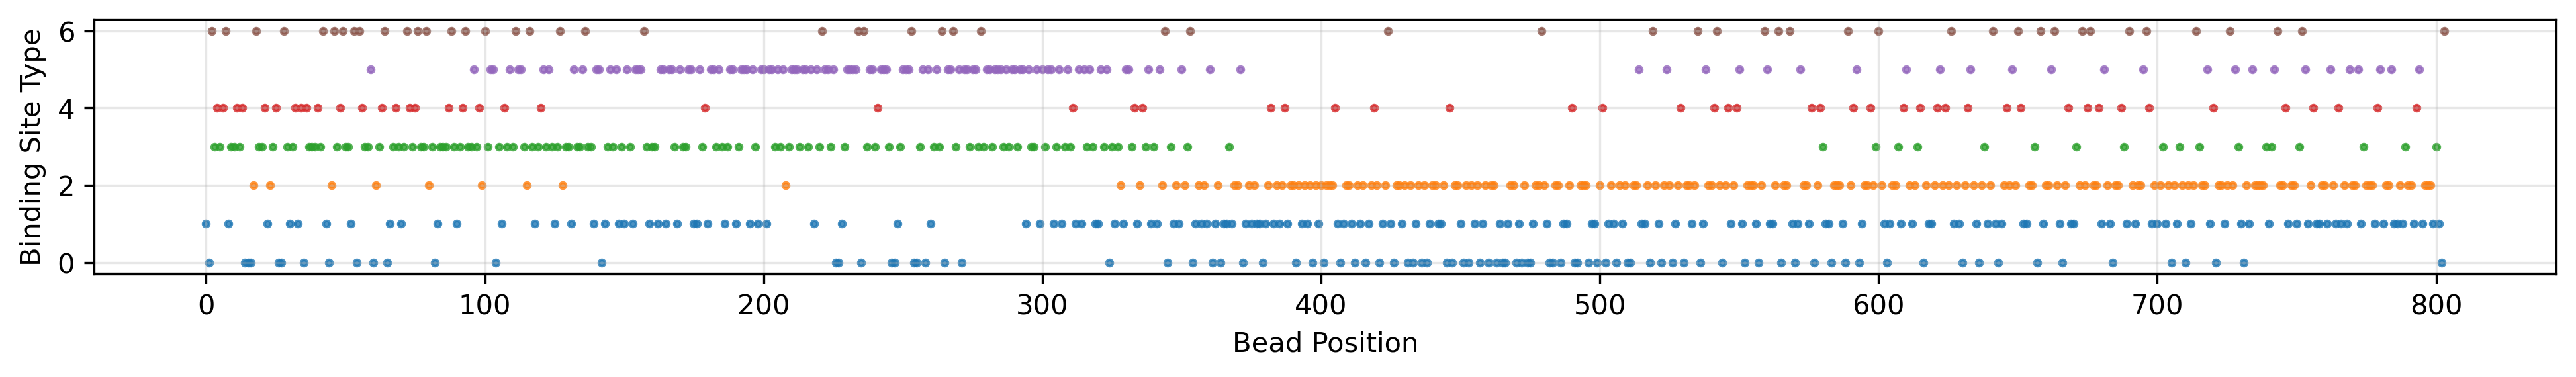

In [54]:

mat_construct = np.log10(contstruct_contact_matrix(
                alpha=1,
                alpscal=contour_scale, # lower: narrower
                polymer_config=last_config,
                coil_profile=coil_profile,
                globule_profile=globule_profile,
                distance_matrix=distance_index(NR)
            ))

zoomed_construct_mat = gaussian_then_stride(mat_construct, N, sigma=None, mode='reflect') * mat_multiplier
'''
plt.imshow(zoomed_construct_mat, cmap="Reds",)
plt.colorbar()
plt.title("Constructed Matrix")
'''

visualize_config(last_config, num_classes=K)

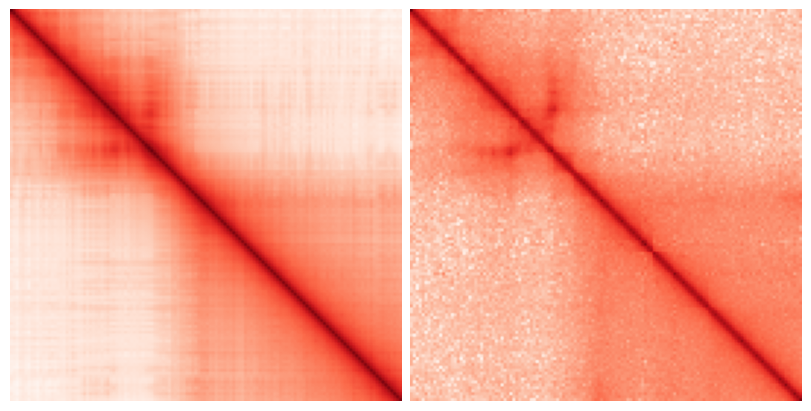

<Figure size 1920x1440 with 0 Axes>

In [55]:
mat1 = zoomed_construct_mat
mat2 = processed_log_matrix  # or use another matrix

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
axes[0].imshow(mat1, cmap="Reds")
axes[1].imshow(mat2, cmap="Reds")

for ax in axes:
    ax.set_axis_off()

plt.figure(dpi=300)
plt.show()


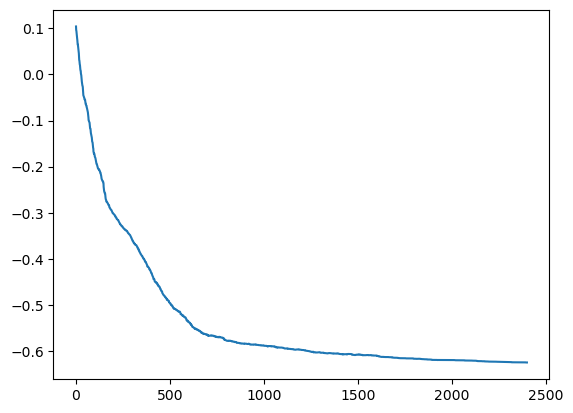

In [56]:
plt.plot(rmse_history[1:])

Text(0.5, 1.0, 'Constructed Matrix')

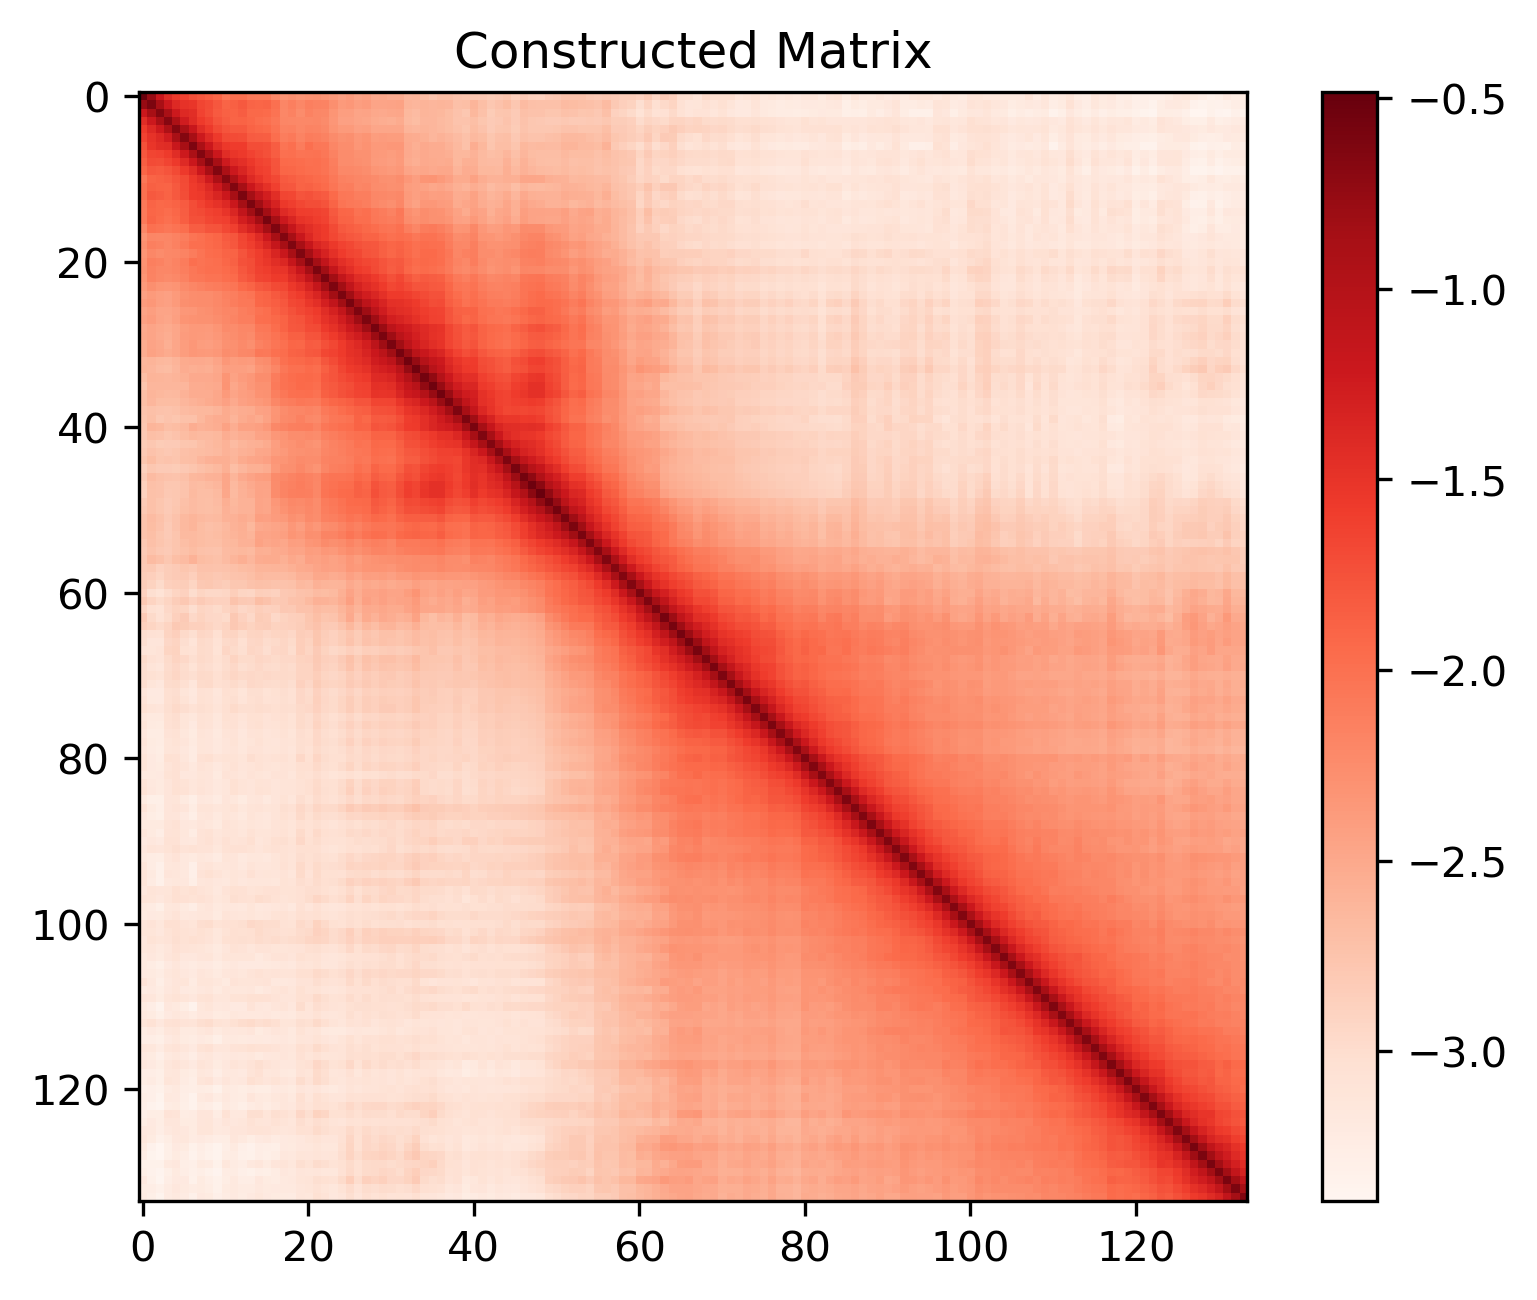

In [57]:
plt.figure(dpi=300)
plt.imshow(zoomed_construct_mat, cmap="Reds",)
plt.colorbar()
plt.title("Constructed Matrix")

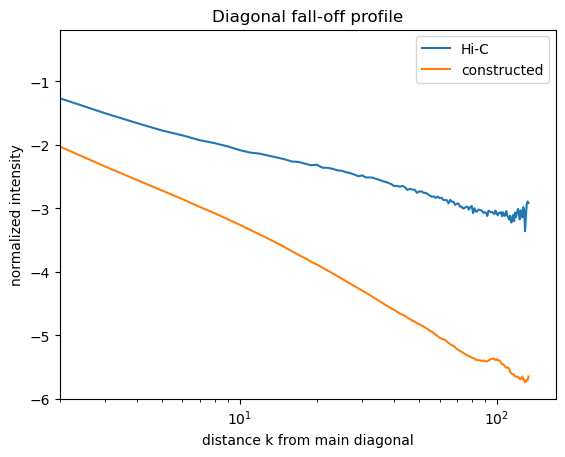

In [58]:
decay, horiz, vert = diagonal_decay_profile(processed_log_matrix, agg="mean", normalize=False)

zoomed_construct_mat = gaussian_then_stride(mat_construct, N, sigma=None, mode='reflect')

decay2, horiz, vert = diagonal_decay_profile(zoomed_construct_mat, agg="mean", normalize=False)
plt.plot(decay, label = "Hi-C")
plt.plot(decay2, label = "constructed")
plt.xlabel("distance k from main diagonal")
plt.ylabel("normalized intensity")
plt.xscale("log")
plt.xlim(left = 2)
plt.title("Diagonal fall-off profile")
plt.legend()
plt.show()


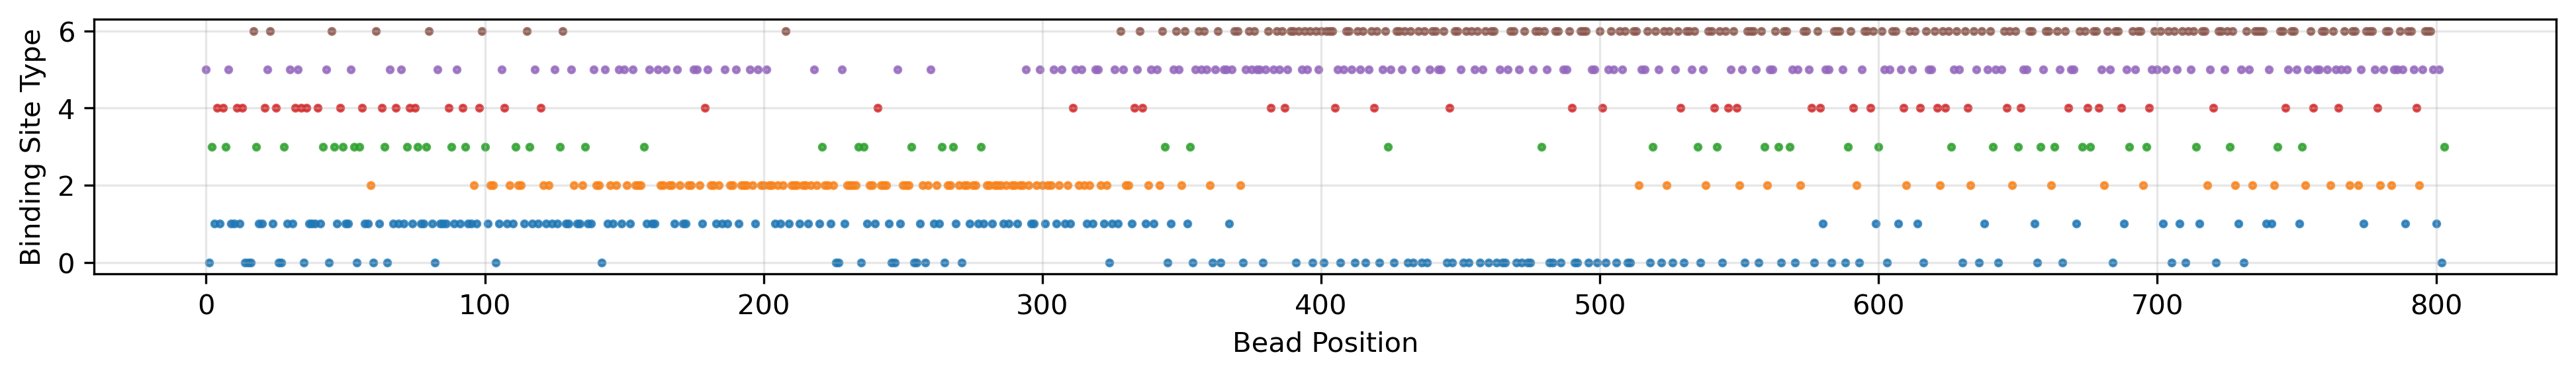

In [59]:
sort_config = sort_classes_by_com(last_config)
visualize_config(sort_config, num_classes=K)

In [60]:
mat_multis = np.linspace(0.01, 2, 100)
c_scales = np.linspace(0.01, 2, 100)
mat_multis, c_scales, diff_grid = parameter_sweep_2d(mat_multis, c_scales, last_config)
flat_idx = np.argmin(diff_grid)
row_idx, col_idx = np.unravel_index(flat_idx, diff_grid.shape)
#print(row_idx, col_idx)
print("best intensity multiplier = ", mat_multis[row_idx])
print("best contour zoom factor = ", c_scales[col_idx])

mat_multiplier = mat_multis[row_idx]
contour_scale = c_scales[col_idx]

best intensity multiplier =  0.49242424242424243
best contour zoom factor =  0.0301010101010101


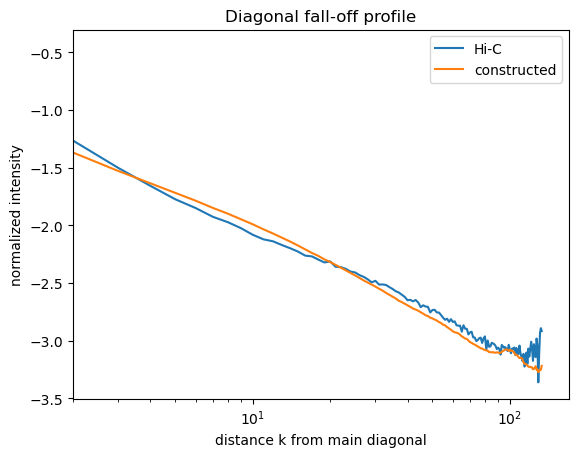

In [61]:
mat_construct = np.log10(contstruct_contact_matrix(
                alpha=1,
                alpscal=contour_scale, # lower: narrower
                polymer_config=last_config,
                coil_profile=coil_profile,
                globule_profile=globule_profile,
                distance_matrix=distance_index(NR)
            ))

zoomed_construct_mat = gaussian_then_stride(mat_construct, N, sigma=None, mode='reflect') * mat_multiplier

decay, horiz, vert = diagonal_decay_profile(processed_log_matrix, agg="mean", normalize=False)

decay2, horiz, vert = diagonal_decay_profile(zoomed_construct_mat, agg="mean", normalize=False)
plt.plot(decay, label="Hi-C")
plt.plot(decay2, label="constructed")
plt.xlabel("distance k from main diagonal")
plt.ylabel("normalized intensity")
plt.xscale("log")
plt.xlim(left=2)
plt.title("Diagonal fall-off profile")
plt.legend()
plt.show()

In [62]:
r, p = pearson_corr_distance_corrected(zoomed_construct_mat, processed_log_matrix)
print('r = ', r)
print('p = ', p)

r =  0.7639497218431702
p =  0.0


In [10]:
rand_mat_construct = contstruct_contact_matrix(
    alpha=1,
    alpscal=contour_scale,
    polymer_config=config_inert,
    coil_profile=coil_profile,
    globule_profile=globule_profile,
    distance_matrix=distance_index(NR)
)
zoomed_ramdom_matrix = zoomed_construct_mat = gaussian_then_stride(rand_mat_construct, N, sigma=None, mode='reflect') * mat_multiplier

r, p = pearson_corr_distance_corrected(zoomed_ramdom_matrix, processed_log_matrix)
print('r = ', r)
print('p = ', p)

r =  -0.04367050384715288
p =  3.72670526458598e-05
